# Combined Cycle Power Plant
**Name:** Nakul Kumbria

**GitHub Username:** nakicool007

**USC ID:** 6748597520

In [1]:
%pip install openpyxl numpy pandas matplotlib seaborn scikit-learn statsmodels


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, f1_score
from sklearn.neighbors import KNeighborsClassifier

# 1.B

# (i)

In [3]:
from pathlib import Path

data_path = Path("data") / "combined_cycle_power_plant" / "Folds5x2_pp.xlsx"
if not data_path.is_file():
    data_path = Path("..") / data_path

df = pd.read_excel(
    data_path,
    sheet_name=0
)
print(len(df))
print(len(df.columns))


9568
5


Each **row** represents one observation of the power plant operating at full load, using hourly average measurements.

The **columns** represent:

- **AT**: Ambient temperature (°C).
- **V**: Exhaust vacuum (cm Hg).
- **AP**: Ambient pressure (millibars).
- **RH**: Relative humidity (%).
- **PE**: Net electrical energy output (MW), the target you want to predict.

The first four columns are the **predictors**, and **PE** is the **response**.

# (ii)

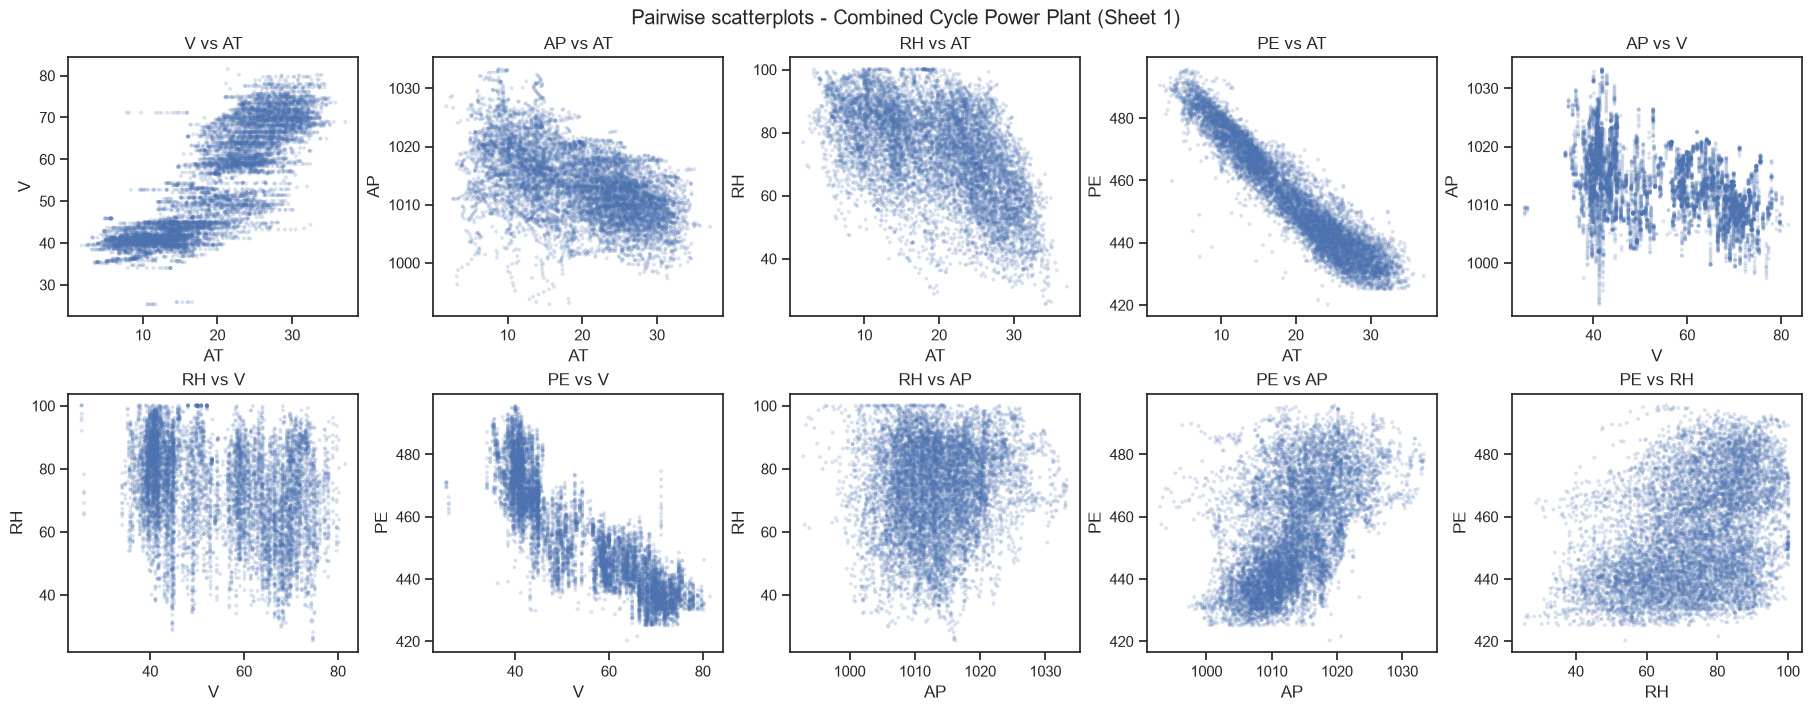

In [4]:
from itertools import combinations

variables = ["AT", "V", "AP", "RH", "PE"]
sns.set_theme(style="ticks")
fig, axes = plt.subplots(2, 5, figsize=(18, 7), constrained_layout=True)

for ax, (x, y) in zip(axes.flat, combinations(variables, 2)):
    ax.scatter(df[x], df[y], s=8, alpha=0.2, edgecolors="none")
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{y} vs {x}")

fig.suptitle("Pairwise scatterplots - Combined Cycle Power Plant (Sheet 1)")
plt.show()


### Findings

From the plots, I noticed that AT and V have the clearest relationships with PE. As temperature (AT) increases, the power output generally decreases. The points follow a fairly straight downward pattern. V also has a strong negative relationship with PE, but its points form groups and the pattern is not as straight.

AP has a positive relationship with PE, meaning higher pressure tends to go along with higher output. However, the points are more spread out than in the AT and V plots. RH also shows a positive trend with PE, but it is weaker and there is a lot of scatter.

The predictors also have relationships with each other. AT and V have a strong positive relationship. AT tends to decrease as AP or RH increases, and V has similar but weaker negative trends with AP and RH. There is little clear relationship between AP and RH. Since AT and V are closely related, they may provide some overlapping information when used together in a model.

Overall, AT and V seem to be the most useful individual predictors of PE based on these plots. Some plots have curved patterns or points away from the main group, which would be worth looking into further. These patterns show associations, but they do not tell us whether one variable causes changes in another.


# (iii)

In [5]:
summary = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Range": df.max() - df.min(),
    "First quartile (Q1)": df.quantile(0.25),
    "Third quartile (Q3)": df.quantile(0.75),
    "IQR": df.quantile(0.75) - df.quantile(0.25),
})
summary.index.name = "Variable"
summary.round(3)


,Mean,Median,Range,First quartile (Q1),Third quartile (Q3),IQR
Variable,,,,,,
AT,19.651,20.345,35.30,13.510,25.72,12.210
V,54.306,52.080,56.20,41.740,66.54,24.800
AP,1013.259,1012.940,40.41,1009.100,1017.26,8.160
RH,73.309,74.975,74.60,63.328,84.83,21.502
PE,454.365,451.550,75.50,439.750,468.43,28.680


# 1.C

In [6]:
from scipy import stats

# Fit PE = intercept + slope * predictor separately for each predictor.
predictors = ["AT", "V", "AP", "RH"]
y = df["PE"]
n = len(df)
models = {}
regression_rows = []
outlier_rows = []

for predictor in predictors:
    x = df[predictor]
    model = stats.linregress(x, y)
    fitted = model.intercept + model.slope * x
    residuals = y - fitted

    # Account for residual scale and each observation's leverage.
    leverage = 1 / n + (x - x.mean()) ** 2 / ((x - x.mean()) ** 2).sum()
    residual_sd = np.sqrt((residuals ** 2).sum() / (n - 2))
    standardized_residuals = residuals / (residual_sd * np.sqrt(1 - leverage))
    flagged = standardized_residuals.abs() > 3

    # Two-sided 95% confidence interval for the slope.
    margin = stats.t.ppf(0.975, df=n - 2) * model.stderr
    regression_rows.append({
        "Predictor": predictor,
        "Intercept": model.intercept,
        "Slope": model.slope,
        "Slope SE": model.stderr,
        "95% CI lower": model.slope - margin,
        "95% CI upper": model.slope + margin,
        "R-squared": model.rvalue ** 2,
        "Slope p-value": "< 0.001" if model.pvalue < 0.001 else f"{model.pvalue:.4f}",
        "Significant (5%)": model.pvalue < 0.05,
        "Potential outliers": int(flagged.sum()),
    })
    models[predictor] = {
        "fit": model, "fitted": fitted,
        "standardized_residuals": standardized_residuals,
        "flagged": flagged,
    }
    for index in df.index[flagged]:
        outlier_rows.append({
            "Predictor": predictor,
            "DataFrame index": index,
            "Predictor value": x.loc[index],
            "PE": y.loc[index],
            "Standardized residual": standardized_residuals.loc[index],
        })

regression_summary = pd.DataFrame(regression_rows).set_index("Predictor")
# Keep the flagged observations available for inspection without deleting them.
potential_outliers = pd.DataFrame(outlier_rows)
regression_summary.round(4)


,Intercept,Slope,Slope SE,95% CI lower,95% CI upper,R-squared,Slope p-value,Significant (5%),Potential outliers
Predictor,,,,,,,,,
AT,497.0341,-2.1713,0.0074,-2.1859,-2.1567,0.8989,< 0.001,True,42
V,517.8015,-1.1681,0.0068,-1.1814,-1.1549,0.7565,< 0.001,True,33
AP,-1055.2610,1.4899,0.0251,1.4406,1.5391,0.2688,< 0.001,True,29
RH,420.9618,0.4557,0.0110,0.4341,0.4772,0.1519,< 0.001,True,2


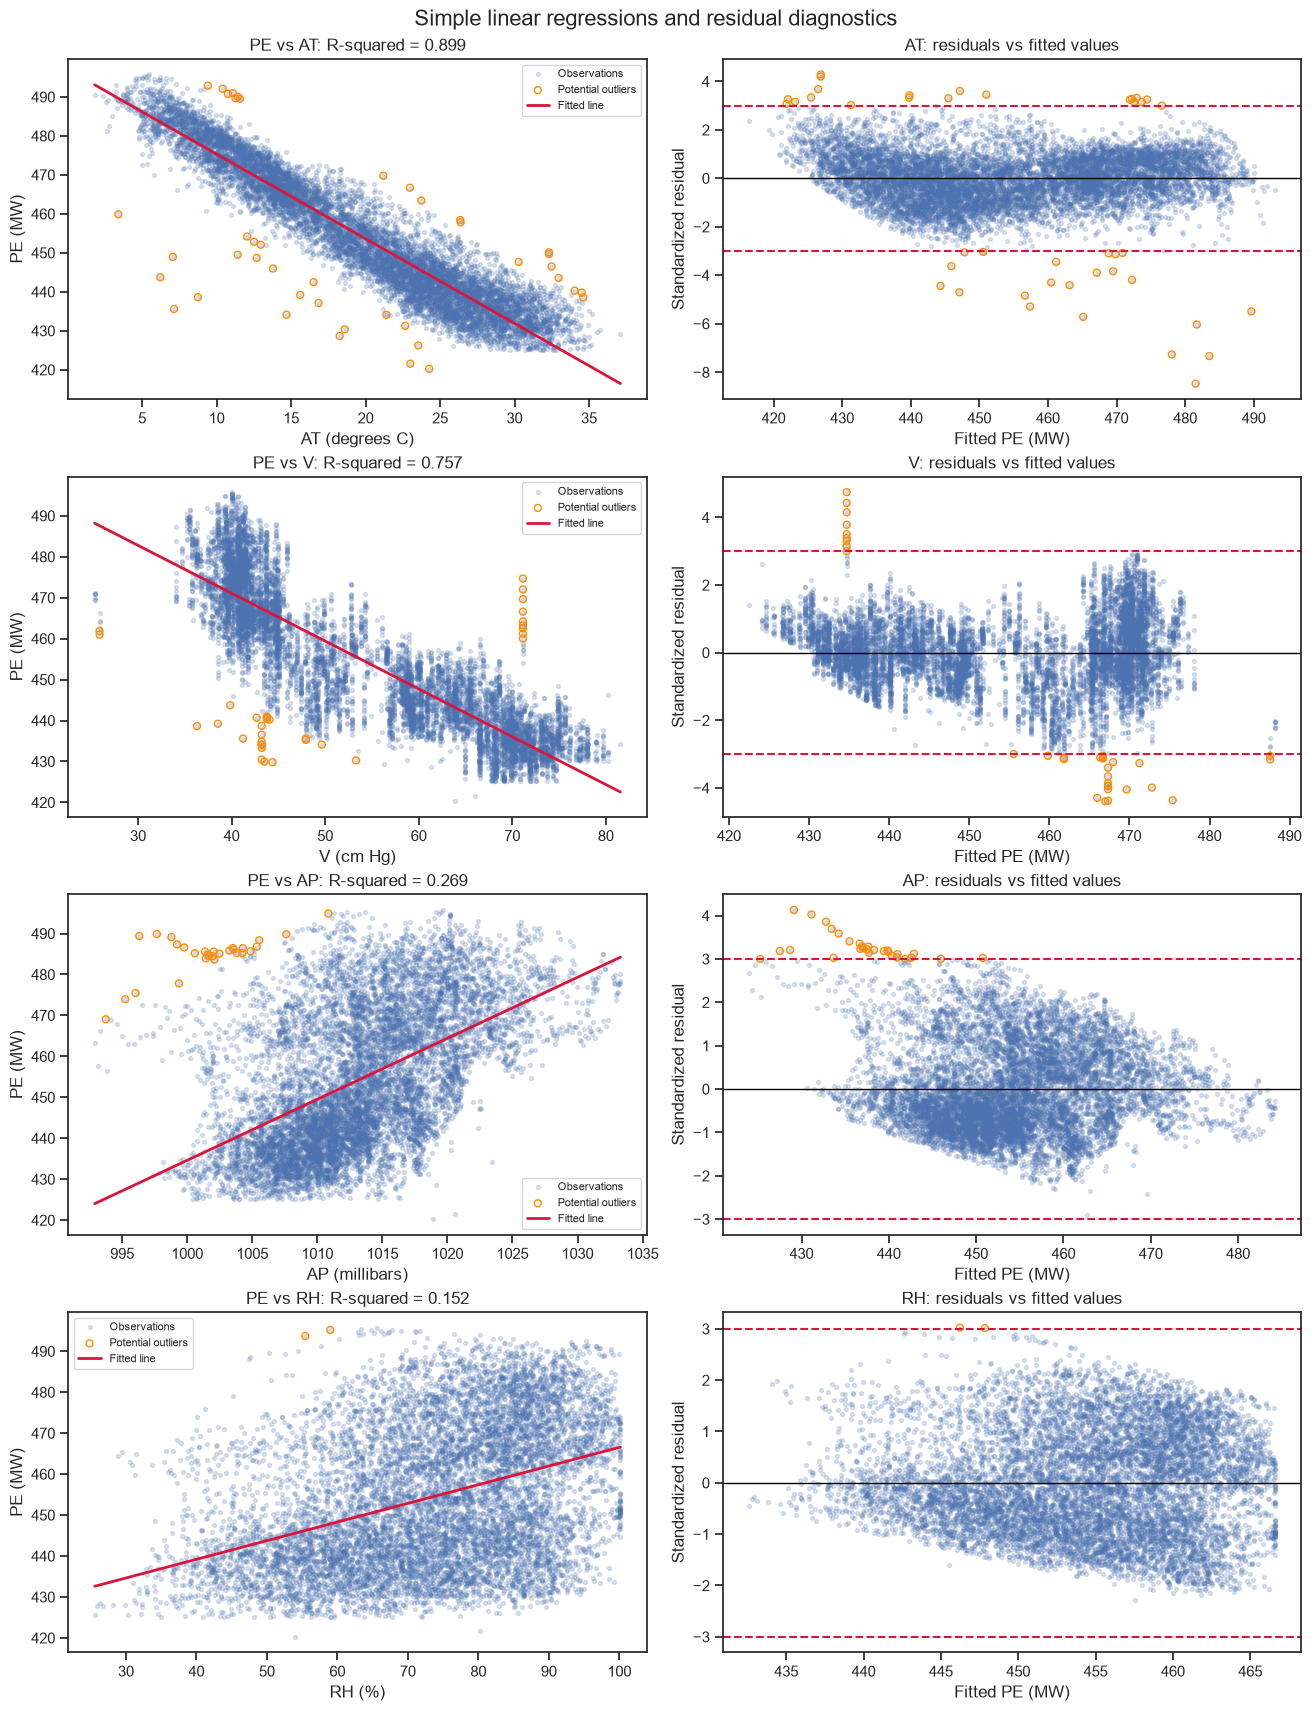

In [7]:
sns.set_theme(style="ticks")
fig, axes = plt.subplots(4, 2, figsize=(13, 17), constrained_layout=True)
units = {"AT": "AT (degrees C)", "V": "V (cm Hg)",
         "AP": "AP (millibars)", "RH": "RH (%)"}

for row, predictor in enumerate(predictors):
    x = df[predictor]
    result = models[predictor]
    flagged = result["flagged"]
    fit = result["fit"]
    x_line = np.linspace(x.min(), x.max(), 100)

    ax = axes[row, 0]
    ax.scatter(x, y, s=8, alpha=0.2, label="Observations")
    ax.scatter(x[flagged], y[flagged], s=25, facecolors="none",
               edgecolors="darkorange", label="Potential outliers")
    ax.plot(x_line, fit.intercept + fit.slope * x_line,
            color="crimson", linewidth=2, label="Fitted line")
    ax.set(xlabel=units[predictor], ylabel="PE (MW)",
           title=f"PE vs {predictor}: R-squared = {fit.rvalue ** 2:.3f}")
    ax.legend(fontsize=8)

    ax = axes[row, 1]
    ax.scatter(result["fitted"], result["standardized_residuals"],
               s=8, alpha=0.2)
    ax.scatter(result["fitted"][flagged],
               result["standardized_residuals"][flagged],
               s=25, facecolors="none", edgecolors="darkorange")
    ax.axhline(0, color="black", linewidth=1)
    ax.axhline(3, color="crimson", linestyle="--")
    ax.axhline(-3, color="crimson", linestyle="--")
    ax.set(xlabel="Fitted PE (MW)", ylabel="Standardized residual",
           title=f"{predictor}: residuals vs fitted values")

fig.suptitle("Simple linear regressions and residual diagnostics", fontsize=16)
plt.show()


### Results

I fitted a separate model for each predictor, with PE as the response. For each model, I tested whether the slope was zero using a two-sided test at the 5% significance level.

- **AT:** The fitted equation is **PE = 497.034 - 2.171 AT**. A one-degree increase in temperature is associated with about 2.17 MW lower output in this model. Its R-squared is about **0.899**, so temperature alone explains about 89.9% of the variation in PE. This is the strongest of the four fits.
- **V:** The fitted equation is **PE = 517.802 - 1.168 V**. Output tends to decrease as V increases. Its R-squared is about **0.757**, which is a fairly strong fit, although the points form groups around the line.
- **AP:** The fitted equation is **PE = -1055.261 + 1.490 AP**. Higher pressure is associated with higher output. Its R-squared is about **0.269**, so it explains much less of the variation than AT or V.
- **RH:** The fitted equation is **PE = 420.962 + 0.456 RH**. A one-percentage-point increase in humidity is associated with about 0.46 MW higher output. Its R-squared is about **0.152**, making it the weakest individual fit.

All four slope p-values are **below 0.001**, and none of the 95% confidence intervals for the slopes include zero. I would therefore reject the zero-slope null hypothesis for every model. This means all four predictors have statistically significant associations with PE under the usual simple-regression assumptions. However, significance does not mean the model predicts well: AP and RH still leave most of the variation unexplained. These are separate associations, without controlling for the other predictors. The intercepts describe where the fitted lines cross zero and should not be interpreted as realistic output at conditions outside the observed data.

### Potential outliers

I flagged observations with an absolute standardized residual greater than 3. These are the orange outlined points in the plots. This identifies points with unusual PE values relative to each fitted line, rather than just points with extreme predictor values.

- **AT:** 42 observations are flagged. I would inspect them because most of the data follow the fitted line fairly closely.
- **V:** 33 observations are flagged. I would check them, but the grouped pattern also suggests that a single straight line does not capture everything in the data.
- **AP:** 29 observations are flagged. Since this model has a weaker fit, I would also consider whether the missing predictors explain these observations.
- **RH:** 2 observations are flagged. Having fewer flagged points does not mean this is the best model. The overall residual spread is large, which makes the cutoff for flagging points larger too.

I would consider removing some of the major outliers, especially the points far below the line in the AT plot. I would first check that they are errors or do not belong in this analysis. Then I would fit the model again and compare the results. I would not remove all the flagged points, since some could be valid data. For now, I have left them in the dataset.

The residual plots show that the models still miss some patterns. AT has a curved residual pattern despite its high R-squared. V shows clear bands and uneven spread. AP has a curved pattern, with large positive residuals at low fitted values, while RH has a broad, uneven residual spread. These patterns suggest that a simple straight-line model does not fully describe the data for any of the four predictors. The reported tests and confidence intervals use the usual assumptions of independent errors with constant variance, so these diagnostics matter when interpreting the results.


# 1.D


In [8]:
import statsmodels.api as sm

# Include all four predictors and keep all observations from Sheet 1.
X_multiple = sm.add_constant(df[["AT", "V", "AP", "RH"]])
y_multiple = df["PE"]
multiple_model = sm.OLS(y_multiple, X_multiple).fit()

print(multiple_model.summary())


                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:14:44   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

### Results

I used AT, V, AP, and RH together to predict PE. The fitted equation is:

$$
\widehat{PE} = 454.609 - 1.978\,AT - 0.234\,V + 0.062\,AP - 0.158\,RH
$$

The model has an R-squared of about **0.929**, which means it explains about **92.9% of the variation in PE**. This is better than the simple model using AT alone, which had an R-squared of about 0.899. However, I would still need to test the models on new data to compare how well they predict.

At a **5% significance level**, I would reject **H0: the coefficient is zero** for **all four predictors**. Their p-values are all below 0.001, so each predictor is significant even with the other predictors in the model. The p-values displayed as 0.000 are just rounded to three decimal places.

If the other predictors stay the same, increasing AT by 1 degree is associated with about 1.978 MW less output. Increasing V by 1 cm Hg is associated with about 0.234 MW less output, while increasing AP by 1 millibar is associated with about 0.062 MW more output. A 1-percentage-point increase in RH is associated with about 0.158 MW less output.

I noticed that RH has a negative coefficient here, even though it was positive in the simple regression. This is because the multiple regression also takes the other predictors into account. Since the predictors are related to each other, looking at them together can give different results from looking at each one separately.

I kept the potential outliers in the data for this model. The significance tests assume independent errors with constant variance.


# 1.E

    Simple regression (1c)  Multiple regression (1d)
AT                 -2.1713                   -1.9775
V                  -1.1681                   -0.2339
AP                  1.4899                    0.0621
RH                  0.4557                   -0.1581


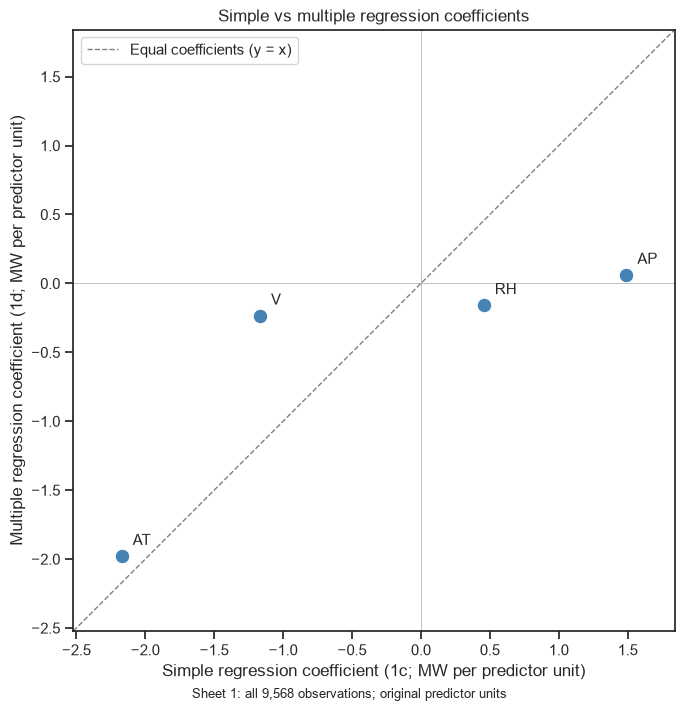

In [9]:
# Compare predictor slopes from 1.C and 1.D (exclude the intercept).
coefficient_comparison = pd.DataFrame({
    "Simple regression (1c)": regression_summary.loc[predictors, "Slope"],
    "Multiple regression (1d)": multiple_model.params.loc[predictors],
})
print(coefficient_comparison.round(4).to_string())

fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
simple = coefficient_comparison["Simple regression (1c)"]
multiple = coefficient_comparison["Multiple regression (1d)"]
ax.scatter(simple, multiple, s=75, color="steelblue", zorder=3)
for predictor in predictors:
    ax.annotate(predictor, (simple.loc[predictor], multiple.loc[predictor]),
                xytext=(8, 8), textcoords="offset points", fontsize=11)

# Equal axis scales make the y = x line a direct equality reference.
lower = coefficient_comparison.to_numpy().min() - 0.35
upper = coefficient_comparison.to_numpy().max() + 0.35
ax.plot([lower, upper], [lower, upper], linestyle="--", color="gray",
        linewidth=1, label="Equal coefficients (y = x)")
ax.axhline(0, color="gray", linewidth=0.7, alpha=0.5)
ax.axvline(0, color="gray", linewidth=0.7, alpha=0.5)
ax.set(xlim=(lower, upper), ylim=(lower, upper),
       xlabel="Simple regression coefficient (1c; MW per predictor unit)",
       ylabel="Multiple regression coefficient (1d; MW per predictor unit)",
       title="Simple vs multiple regression coefficients")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper left")
fig.supxlabel("Sheet 1: all 9,568 observations; original predictor units", fontsize=9)
plt.show()


### Comparison

The coefficients change when the other predictors are included:

- **AT:** -2.1713 in 1c versus -1.9775 in 1d. Its negative association changes relatively little, so its point is close to the equality line.
- **V:** -1.1681 versus -0.2339. Its negative coefficient becomes much smaller in magnitude.
- **AP:** 1.4899 versus 0.0621. Its positive coefficient becomes much smaller and moves close to zero.
- **RH:** 0.4557 versus -0.1581. Its association changes from positive to negative after adjusting for the other predictors.

The simple regressions describe each predictor's association with PE on its own. The multiple regression describes its association with PE while holding the other three predictors constant. Because the predictors are correlated, their simple regression slopes also reflect variation shared with other predictors. This helps explain the reductions for V and AP and the sign reversal for RH. All four predictors remain statistically significant in 1d, even though their coefficients change.

The plot uses unstandardized coefficients, as requested. Each point compares the same predictor across models; coefficient magnitudes across different predictors should not be treated as a ranking of importance because their measurement units differ.


# 1.F

I fitted a separate cubic regression for AT, V, AP, and RH, using PE as the response. I kept all the observations from Sheet 1. For each predictor, I compared the cubic model with the simple linear model using an F-test. The null hypothesis is that the coefficients of the squared and cubed terms are both zero. A p-value below 0.05 would give evidence of a nonlinear relationship.

Before creating the squared and cubed terms, I subtracted each predictor's mean and divided by its standard deviation. This helps avoid very large numbers, especially for AP. It gives the same fitted curve and overall test of nonlinearity as using the original values. The coefficients shown below are for these scaled values.


In [10]:
import statsmodels.api as sm

predictors = ["AT", "V", "AP", "RH"]
polynomial_models = {}
nonlinearity_rows = []

for predictor in predictors:
    x = df[predictor]
    # Scaling improves numerical stability, especially for AP near 1,000.
    # A cubic in z spans exactly the same models as a cubic in X.
    center, scale = x.mean(), x.std()
    z = (x - center) / scale
    X_cubic = pd.DataFrame({"const": 1.0, "z": z, "z2": z**2, "z3": z**3})
    cubic_model = sm.OLS(df["PE"], X_cubic).fit()
    linear_model = sm.OLS(df["PE"], X_cubic[["const", "z"]]).fit()

    # Joint test H0: beta_2 = beta_3 = 0 against a cubic alternative.
    f_stat, p_value, df_difference = cubic_model.compare_f_test(linear_model)
    polynomial_models[predictor] = {
        "cubic": cubic_model, "linear": linear_model,
        "center": center, "scale": scale,
    }
    nonlinearity_rows.append({
        "Predictor": predictor,
        "Linear R-squared": linear_model.rsquared,
        "Cubic R-squared": cubic_model.rsquared,
        "Quadratic p-value (scaled basis)": cubic_model.pvalues["z2"],
        "Cubic p-value": cubic_model.pvalues["z3"],
        "Joint F-statistic": f_stat,
        "Joint p-value": p_value,
        "Nonlinear (5%)": p_value < 0.05,
    })

nonlinearity_summary = pd.DataFrame(nonlinearity_rows).set_index("Predictor")
print(nonlinearity_summary.to_string(float_format=lambda value: f"{value:.6g}"))
print("\nA p-value displayed as 0 is below floating-point precision, not exactly zero.")
print("\nCubic coefficients for z = (X - mean(X)) / std(X):")
polynomial_coefficients = pd.DataFrame({
    predictor: result["cubic"].params
    for predictor, result in polynomial_models.items()
}).T
print(polynomial_coefficients.round(6).to_string())


           Linear R-squared  Cubic R-squared  Quadratic p-value (scaled basis)  Cubic p-value  Joint F-statistic  Joint p-value  Nonlinear (5%)
Predictor                                                                                                                                      
AT                 0.898948         0.911883                      3.31181e-231   3.65218e-110            701.967   3.47838e-285            True
V                  0.756518         0.775022                      8.97701e-131      0.0137349            393.314    7.0403e-165            True
AP                 0.268769         0.297543                       2.19272e-46    2.12334e-67            195.886    4.20915e-84            True
RH                 0.151939         0.153743                          0.101395    1.44028e-05            10.1889    3.79962e-05            True

A p-value displayed as 0 is below floating-point precision, not exactly zero.

Cubic coefficients for z = (X - mean(X)) / std(X):
     

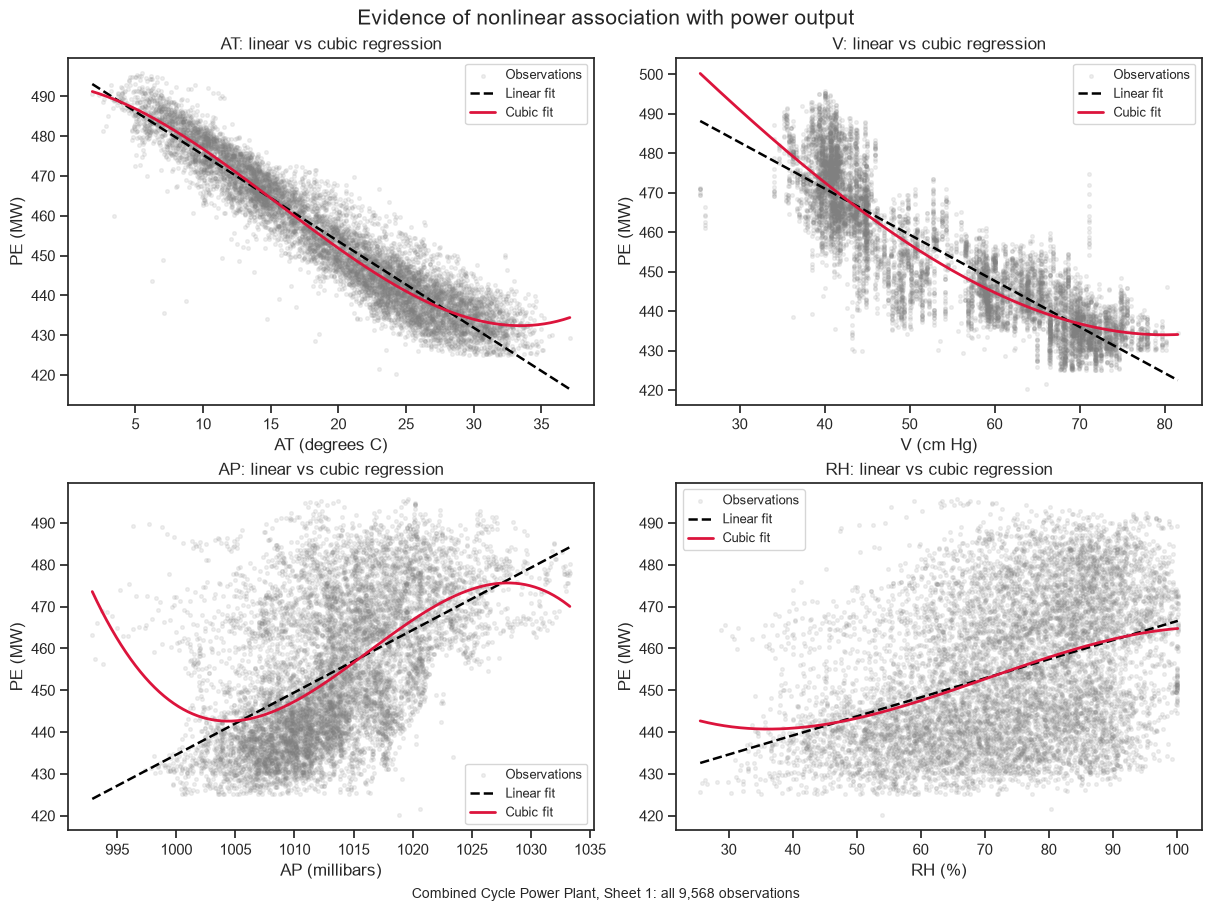

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
units = {"AT": "AT (degrees C)", "V": "V (cm Hg)",
         "AP": "AP (millibars)", "RH": "RH (%)"}

for ax, predictor in zip(axes.flat, predictors):
    result = polynomial_models[predictor]
    x_grid = np.linspace(df[predictor].min(), df[predictor].max(), 300)
    z_grid = (x_grid - result["center"]) / result["scale"]
    grid = pd.DataFrame({"const": 1.0, "z": z_grid,
                         "z2": z_grid**2, "z3": z_grid**3})
    ax.scatter(df[predictor], df["PE"], s=7, alpha=0.12,
               color="gray", rasterized=True, label="Observations")
    ax.plot(x_grid, result["linear"].predict(grid[["const", "z"]]),
            color="black", linestyle="--", linewidth=1.8, label="Linear fit")
    ax.plot(x_grid, result["cubic"].predict(grid),
            color="crimson", linewidth=2, label="Cubic fit")
    ax.set(xlabel=units[predictor], ylabel="PE (MW)",
           title=f"{predictor}: linear vs cubic regression")
    ax.legend(fontsize=9)

fig.suptitle("Evidence of nonlinear association with power output", fontsize=15)
fig.supxlabel("Combined Cycle Power Plant, Sheet 1: all 9,568 observations", fontsize=10)
plt.show()


### Results

I found evidence of a nonlinear relationship with PE for **all four predictors**, since all the F-test p-values are below 0.05.

- **AT:** The p-value is about **3.48e-285**, and R-squared increases from **0.8989 to 0.9119**. The cubic curve follows the data better at higher temperatures, where the relationship starts to flatten out.
- **V:** The p-value is about **7.04e-165**, and R-squared increases from **0.7565 to 0.7750**. The cubic curve shows that the decrease in PE becomes less steep at higher values of V.
- **AP:** The p-value is about **4.21e-84**, and R-squared increases from **0.2688 to 0.2975**. The curve bends more clearly than the straight line, although there is still a lot of scatter around it.
- **RH:** The p-value is about **3.80e-5**, and R-squared increases from **0.1519 to 0.1537**. This is statistically significant, but the improvement is very small. The linear and cubic fits look similar over much of the data.

The cubed term is significant for all four predictors. For RH, the squared term in the scaled model has a p-value of about **0.101**, so it is not significant by itself. However, the F-test checks the squared and cubed terms together, and that test still gives evidence of nonlinearity.

Overall, the cubic models fit the data better than the simple linear models, but the improvement is much smaller for RH. These results are for each predictor separately. They do not tell me whether the same nonlinear relationships would remain after including the other predictors. Also, a better fit on this dataset does not necessarily mean better predictions on new data. The tests assume independent, normally distributed errors with constant variance.


# 1.G

I used AT, V, AP, and RH together to predict PE and added all six pairwise interaction terms. Each interaction is the product of two predictors, such as AT times V. The model is:

$$
PE = \beta_0 + \beta_1 AT + \beta_2 V + \beta_3 AP + \beta_4 RH
+ \beta_5(AT\times V) + \beta_6(AT\times AP) + \beta_7(AT\times RH)
+ \beta_8(V\times AP) + \beta_9(V\times RH) + \beta_{10}(AP\times RH) + \epsilon.
$$

I used all the observations from Sheet 1. To check which interactions were significant, I compared their p-values with 0.05.


In [12]:
import statsmodels.formula.api as smf

# Include all four main effects and all six pairwise interactions.
# In a Patsy formula, ** 2 adds interactions up to order two, not squared terms.
interaction_model = smf.ols("PE ~ (AT + V + AP + RH) ** 2", data=df).fit()
print(interaction_model.summary())

interaction_terms = [term for term in interaction_model.params.index if ":" in term]
interaction_ci = interaction_model.conf_int().loc[interaction_terms]
interaction_summary = pd.DataFrame({
    "Coefficient": interaction_model.params.loc[interaction_terms],
    "Standard error": interaction_model.bse.loc[interaction_terms],
    "t-statistic": interaction_model.tvalues.loc[interaction_terms],
    "p-value": interaction_model.pvalues.loc[interaction_terms],
    "95% CI lower": interaction_ci[0],
    "95% CI upper": interaction_ci[1],
    "Significant (5%)": interaction_model.pvalues.loc[interaction_terms] < 0.05,
})
print("\nTests for individual interaction terms:")
print(interaction_summary.to_string(float_format=lambda value: f"{value:.6g}"))

# Also test whether the six interactions together improve the additive model.
additive_model = smf.ols("PE ~ AT + V + AP + RH", data=df).fit()
interaction_f, interaction_p, interaction_df = interaction_model.compare_f_test(additive_model)
print(f"\nJoint interaction test: F({int(interaction_df)}, "
      f"{int(interaction_model.df_resid)}) = {interaction_f:.4f}, p = {interaction_p:.6g}")
print(f"R-squared: additive = {additive_model.rsquared:.6f}, "
      f"with interactions = {interaction_model.rsquared:.6f}")
print("A p-value displayed as 0 is too small to represent numerically, not exactly zero.")


                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:14:45   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

### Results

Yes, there is evidence that some interactions are associated with PE. I found that **four of the six interactions have p-values below 0.05**:

- **AT and V:** p = **3.33e-117**, so it is significant.
- **AT and AP:** p = **0.4521**, so it is not significant.
- **AT and RH:** p = **1.22e-10**, so it is significant.
- **V and AP:** p = **2.88e-7**, so it is significant.
- **V and RH:** p = **0.0862**, so it is not significant.
- **AP and RH:** p = **0.0336**, so it is significant.

These p-values are rounded. I would reject the null hypothesis that the interaction coefficient is zero for **AT:V, AT:RH, V:AP, and AP:RH**. For the other two interactions, there is not enough evidence to reject it at the 5% level.

The interactions suggest that the relationship between one predictor and PE can depend on another predictor. For example, the significant AT:V term suggests that the relationship between temperature and power output changes with the value of V. This result takes the other terms in the model into account.

Adding the interactions increased R-squared from **0.9287 in 1d to 0.9363**. I also tested all six interactions together and got an F-statistic of **190.30** with a p-value of about **8.06e-230**. This supports including interactions, although the increase in R-squared is fairly small. I would still need to check performance on new data to know whether predictions improve.

I kept all four original predictors in the model along with the interactions. I used 0.05 for each test without a multiple-testing adjustment, so the significance results above are based on that cutoff. The tests use the usual regression assumptions about the errors.


# 1.H

I randomly split the data into 70% for training and 30% for testing. I used a random seed of 42 so I could get the same split again. Both models used the same training and test sets.

For the first model, I used AT, V, AP, and RH to predict PE. For the second model, I also added the four squared terms and all six pairwise interactions. I removed the term with the highest p-value above 0.05, fitted the model again, and repeated this until there were no more terms I could remove.

I was careful to keep a predictor if its squared term or an interaction involving it was still included. For example, keeping AT:V means I also need to keep AT and V, even if their individual p-values are above 0.05.

I scaled the predictors using the training means and standard deviations to avoid numerical problems. I used the same values to scale the test data. I only used the training data to decide which terms to remove, then calculated the train and test MSEs for both models.


In [13]:
from itertools import combinations
import statsmodels.api as sm

predictors = ["AT", "V", "AP", "RH"]

# Use the same reproducible split for both models.
rng = np.random.default_rng(42)
shuffled_positions = rng.permutation(len(df))
n_train = int(0.70 * len(df))
train_df = df.iloc[shuffled_positions[:n_train]].copy()
test_df = df.iloc[shuffled_positions[n_train:]].copy()
y_train, y_test = train_df["PE"], test_df["PE"]

# Learn scaling from training data only, then apply it to both subsets.
# This preserves the space of linear/quadratic models and improves stability.
training_means = train_df[predictors].mean()
training_scales = train_df[predictors].std()
z_train = (train_df[predictors] - training_means) / training_scales
z_test = (test_df[predictors] - training_means) / training_scales

# Record which main effects each higher-order term depends on.
term_parents = {f"{name}^2": {name} for name in predictors}
term_parents.update({f"{a}:{b}": {a, b} for a, b in combinations(predictors, 2)})

def quadratic_design(z):
    design = sm.add_constant(z, has_constant="add").copy()
    for name in predictors:
        design[f"{name}^2"] = z[name] ** 2
    for a, b in combinations(predictors, 2):
        design[f"{a}:{b}"] = z[a] * z[b]
    return design

X_train_full = quadratic_design(z_train)
X_test_full = quadratic_design(z_test)
main_effect_columns = ["const"] + predictors
baseline_model_h = sm.OLS(y_train, X_train_full[main_effect_columns]).fit()
full_quadratic_model_h = sm.OLS(y_train, X_train_full).fit()

# Backward elimination with strong hierarchy, using training p-values only.
# Never remove a main effect while its square or an interaction remains.
selected_terms_h = list(X_train_full.columns)
elimination_steps = []
alpha = 0.05
while True:
    selected_model_h = sm.OLS(y_train, X_train_full[selected_terms_h]).fit()
    protected_main_effects = set()
    for term in selected_terms_h:
        protected_main_effects.update(term_parents.get(term, set()))
    removable_terms = [term for term in selected_terms_h
                       if term != "const" and term not in protected_main_effects]
    if not removable_terms:
        break
    candidate_pvalues = selected_model_h.pvalues.loc[removable_terms]
    worst_term = candidate_pvalues.idxmax()
    worst_pvalue = candidate_pvalues.loc[worst_term]
    if worst_pvalue <= alpha:
        break
    elimination_steps.append({"Removed term": worst_term,
                              "Training p-value at removal": worst_pvalue})
    selected_terms_h.remove(worst_term)

print(f"Training observations: {len(train_df)}; test observations: {len(test_df)}")
print("\nBackward elimination:")
print(pd.DataFrame(elimination_steps).to_string(index=False)
      if elimination_steps else "No terms removed.")
print("\nFinal model (predictors scaled using training means and standard deviations):")
print(selected_model_h.summary())

# Evaluate only after selecting the model; do not use test errors to remove terms.
model_comparison_rows = []
for label, model, columns in [
    ("Linear: all four predictors", baseline_model_h, main_effect_columns),
    ("Quadratic + interactions: selected", selected_model_h, selected_terms_h),
]:
    train_predictions = model.predict(X_train_full[columns])
    test_predictions = model.predict(X_test_full[columns])
    model_comparison_rows.append({
        "Model": label,
        "Train MSE (MW^2)": np.mean((y_train - train_predictions) ** 2),
        "Test MSE (MW^2)": np.mean((y_test - test_predictions) ** 2),
    })
model_comparison_h = pd.DataFrame(model_comparison_rows).set_index("Model")
print("\nTrain and test errors:")
print(model_comparison_h.round(4).to_string())
print("\nRetained terms:", ", ".join(selected_terms_h))


Training observations: 6697; test observations: 2871

Backward elimination:
Removed term  Training p-value at removal
       AT:AP                     0.785224
        V:RH                     0.446368
         V^2                     0.224759

Final model (predictors scaled using training means and standard deviations):
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.939
Model:                            OLS   Adj. R-squared:                  0.939
Method:                 Least Squares   F-statistic:                     9355.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:14:45   Log-Likelihood:                -19154.
No. Observations:                6697   AIC:                         3.833e+04
Df Residuals:                    6685   BIC:                         3.841e+04
Df Model:                          11        

### Results

The split gave me **6,697 training observations** and **2,871 test observations**. I got the following results:

- **Model with the four original predictors:** Train MSE = **20.5575** and test MSE = **21.2777**.
- **Model with squared terms and interactions after removing insignificant terms:** Train MSE = **17.8569** and test MSE = **18.7383**.

The MSEs are in MW-squared. The second model did better on both sets. Its test MSE was about **11.9% lower**, so the extra terms helped improve predictions on this split.

I removed **AT:AP**, then **V:RH**, and then **V-squared**. Their p-values when removed were **0.7852**, **0.4464**, and **0.2248**, respectively. I checked the p-values again after each removal because changing the model can change the remaining p-values.

The final model included the intercept, all four original predictors, **AT-squared, AP-squared, RH-squared**, and **AT:V, AT:RH, V:AP, AP:RH**. All the remaining predictor terms had p-values below 0.05. The main effects needed for the interactions and squared terms were also kept.

I would choose the second model because it had the lower test MSE. This suggests that the interactions and curved relationships capture some patterns that the first model misses. However, these results are from one random split, so a different split could give slightly different errors. I used p-values to help choose terms, but they do not prove that this is the best possible model.


# 1.I

I ran KNN regression using AT, V, AP, and RH with the same training and test sets from 1.H. I tried k values from 1 to 100 for both the raw and normalized features.

For normalization, I used min-max scaling to put each training feature between 0 and 1. I then used the training minimum and maximum values to scale the test features too. I used Euclidean distance to find the nearest neighbors and averaged their PE values to make predictions.

For each k, I calculated the training and test MSE. I chose the k with the lowest test MSE for each version and plotted both errors against 1/k.


In [14]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler

# Reuse the split from 1.H so the model errors can be compared.
knn_features = ["AT", "V", "AP", "RH"]
X_train_raw = train_df[knn_features].to_numpy()
X_test_raw = test_df[knn_features].to_numpy()
y_train_knn = train_df["PE"].to_numpy()
y_test_knn = test_df["PE"].to_numpy()

knn_scaler = MinMaxScaler()
X_train_normalized = knn_scaler.fit_transform(X_train_raw)
X_test_normalized = knn_scaler.transform(X_test_raw)

knn_rows = []
for feature_type, X_train_knn, X_test_knn in [
    ("Raw", X_train_raw, X_test_raw),
    ("Normalized", X_train_normalized, X_test_normalized),
]:
    for k in range(1, 101):
        knn_model = KNeighborsRegressor(
            n_neighbors=k, weights="uniform", metric="euclidean",
            algorithm="kd_tree",
        )
        knn_model.fit(X_train_knn, y_train_knn)
        # Training predictions include the observation itself as a neighbor.
        train_prediction = knn_model.predict(X_train_knn)
        test_prediction = knn_model.predict(X_test_knn)
        knn_rows.append({
            "Features": feature_type, "k": k, "1/k": 1 / k,
            "Train MSE": np.mean((y_train_knn - train_prediction) ** 2),
            "Test MSE": np.mean((y_test_knn - test_prediction) ** 2),
        })

knn_results = pd.DataFrame(knn_rows)
# Rows are ordered by k, so a tie in test MSE selects the smaller k.
best_knn_results = knn_results.loc[
    knn_results.groupby("Features")["Test MSE"].idxmin()
].set_index("Features")
print("Best k for each feature version (selected by test MSE):")
print(best_knn_results[["k", "Train MSE", "Test MSE"]].round(4).to_string())
best_overall_knn = knn_results.loc[knn_results["Test MSE"].idxmin()]
print(f"\nLowest test MSE: {best_overall_knn['Features']} features, "
      f"k = {int(best_overall_knn['k'])}, "
      f"test MSE = {best_overall_knn['Test MSE']:.4f} MW^2")


Best k for each feature version (selected by test MSE):
            k  Train MSE  Test MSE
Features                          
Normalized  6     9.9151   15.5542
Raw         7    11.6932   16.9652

Lowest test MSE: Normalized features, k = 6, test MSE = 15.5542 MW^2


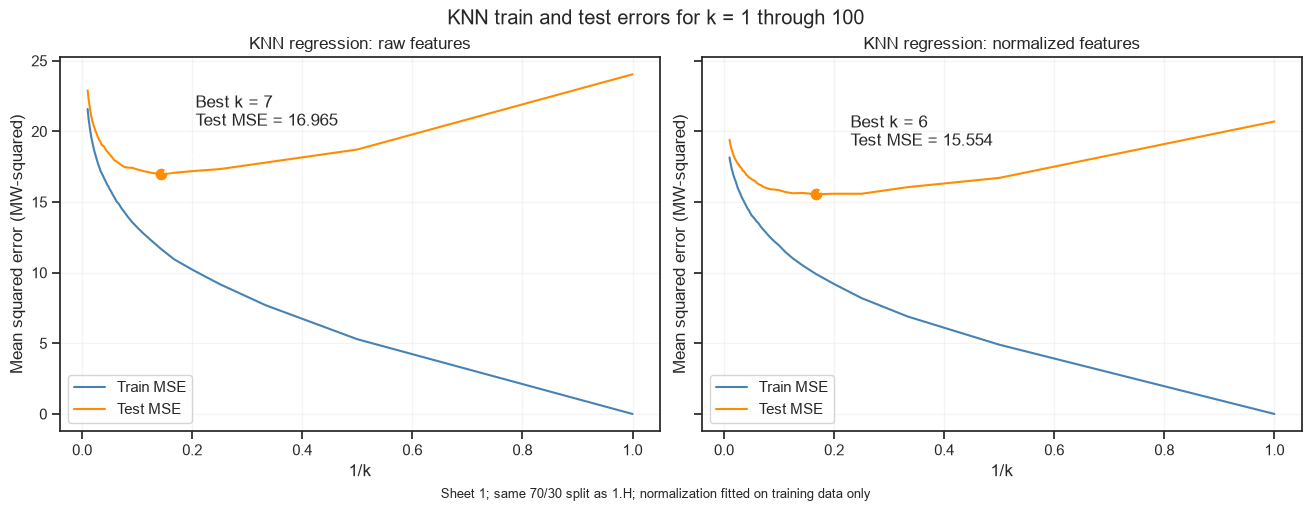

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True, constrained_layout=True)
for ax, feature_type in zip(axes, ["Raw", "Normalized"]):
    curve = knn_results[knn_results["Features"] == feature_type].sort_values("1/k")
    best = best_knn_results.loc[feature_type]
    ax.plot(curve["1/k"], curve["Train MSE"], label="Train MSE", color="steelblue")
    ax.plot(curve["1/k"], curve["Test MSE"], label="Test MSE", color="darkorange")
    ax.scatter(1 / best["k"], best["Test MSE"], color="darkorange", s=55, zorder=3)
    ax.annotate(f"Best k = {int(best['k'])}\nTest MSE = {best['Test MSE']:.3f}",
                (1 / best["k"], best["Test MSE"]), xytext=(25, 35),
                textcoords="offset points", arrowprops={"arrowstyle": "->"})
    ax.set(xlabel="1/k", ylabel="Mean squared error (MW-squared)",
           title=f"KNN regression: {feature_type.lower()} features")
    ax.grid(alpha=0.2)
    ax.legend(loc="lower left")
fig.suptitle("KNN train and test errors for k = 1 through 100")
fig.supxlabel("Sheet 1; same 70/30 split as 1.H; normalization fitted on training data only", fontsize=9)
plt.show()


### Results

With the **raw features**, I got the lowest test error at **k = 7**. The training MSE was **11.6932**, and the test MSE was **16.9652**.

With the **normalized features**, the best value was **k = 6**. The training MSE was **9.9151**, and the test MSE was **15.5542**. All these MSE values are in MW-squared.

I would choose **normalized features with k = 6** because this gave the lowest test MSE. Normalizing helped on this split. Since KNN uses distances, a feature with a larger numerical range can have more influence on which points are considered close. Scaling the features changes these distances and can give better neighbors for prediction.

In the plots, k = 1 is on the right because the horizontal axis is 1/k. At k = 1, the training error is almost zero since each training point can be its own nearest neighbor. However, the test error is higher, which suggests overfitting. Using a few more neighbors lowers the test error, but using too many increases it again because the predictions become too smooth.

These are the best k values for this particular split. Since I used the test errors to choose k, I would need a separate test set to get a more independent check of the chosen model. Another option would be to choose k using cross-validation on the training data before checking the test error.


# 1.J

My best regression model was the one from 1.H with the squared terms and interactions. It had a test MSE of **18.7383**, which was lower than **21.2777** for the model with just the four original predictors. It still counts as linear regression because it is linear in the coefficients.

I compared it with the best KNN models and got these results:

- **Regression with squared terms and interactions:** Train MSE = **17.8569**, test MSE = **18.7383**.
- **Raw KNN with k = 7:** Train MSE = **11.6932**, test MSE = **16.9652**.
- **Normalized KNN with k = 6:** Train MSE = **9.9151**, test MSE = **15.5542**.

All three used the same training and test sets, and the MSEs are in MW-squared. Both KNN models did better on the test set than the regression model. **Normalized KNN with k = 6 was the best**, with a test MSE about **17% lower** than the best regression model.

I think KNN may have done better because it uses nearby observations to make predictions. This lets it follow patterns that one regression equation might miss. Normalization also helped here because the predictors have different ranges, and those ranges affect which points KNN considers close.

KNN had a bigger gap between its training and test errors, so I would not choose it just because its training error was low. However, it also had the lowest test error on this split. I would choose normalized KNN with k = 6 for prediction, while the regression model would be easier to use when explaining the relationships between the predictors and PE.

These results are only for one random split. I also used the test errors to choose k, which could make the best KNN result look better than it would on new data. To check this, I would choose k using cross-validation on the training data and then evaluate it on a separate test set.


# 2.4.1 Flexible vs. Inflexible Methods

For these answers, I am considering how well the model predicts new data.

### (a)

I would expect the flexible method to do **better**. There are a lot of observations and only a few predictors, so the model has enough data to learn patterns without overfitting as easily. If the relationship is already simple, though, there might not be much improvement.

### (b)

I would expect the flexible method to do **worse**. With so many predictors and very few observations, it is easier for the model to fit random patterns in the training data. This can lead to overfitting, so a simpler method would usually do better on new data.

### (c)

I would expect the flexible method to do **better** because it can follow the curves in a highly nonlinear relationship. An inflexible method might miss these patterns and underfit the data.

### (d)

I would expect the flexible method to do **worse**. High error variance means there is a lot of noise, and a flexible model may try to fit that noise. A simpler model is less likely to do this. However, neither method can get rid of the irreducible error.


# 2.4.7 KNN Classification

### (a)

The test point is (0, 0, 0), so I calculated each distance using:

$$
d = \sqrt{(X_1-0)^2 + (X_2-0)^2 + (X_3-0)^2}.
$$

- **Observation 1:** $\sqrt{0^2 + 3^2 + 0^2} = 3$.
- **Observation 2:** $\sqrt{2^2 + 0^2 + 0^2} = 2$.
- **Observation 3:** $\sqrt{0^2 + 1^2 + 3^2} = \sqrt{10} \approx 3.162$.
- **Observation 4:** $\sqrt{0^2 + 1^2 + 2^2} = \sqrt{5} \approx 2.236$.
- **Observation 5:** $\sqrt{(-1)^2 + 0^2 + 1^2} = \sqrt{2} \approx 1.414$.
- **Observation 6:** $\sqrt{1^2 + 1^2 + 1^2} = \sqrt{3} \approx 1.732$.

From closest to farthest, the observations are **5, 6, 2, 4, 1, 3**.

### (b)

For **K = 1**, I would predict **Green**. The closest point is observation 5, with a distance of about 1.414, and its response is Green.

### (c)

For **K = 3**, I would predict **Red**. The three closest points are observations 5, 6, and 2. Their responses are Green, Red, and Red, so Red gets two of the three votes.

### (d)

I would expect the best K to be **small**. A smaller K makes KNN more flexible, so it can follow a highly nonlinear decision boundary more closely. A large K averages over more neighbors and gives a smoother boundary, which could miss these patterns. However, a very small K can also be sensitive to noise, so I would not assume K = 1 is always best.
